In [1]:
import pandas as pd

df = pd.read_csv('data/processed/dataset.csv')
df.head()


,titulo,texto,categoria,archivo_origen
0,Introduccion a Spring Boot,Spring Boot es un framework de Java que simpli...,backend,backend_01.txt
1,Autenticacion con tokens JWT,JSON Web Token es un estandar para transmitir ...,backend,backend_05.txt
2,Arquitectura en capas,La arquitectura en capas organiza el codigo ba...,backend,backend_06.txt
3,Validacion de datos de entrada,Validar los datos que llegan a una API es fund...,backend,backend_07.txt
4,Manejo de excepciones en una API,El manejo centralizado de excepciones permite ...,backend,backend_04.txt


In [3]:
# Revisión de forma general de datos
print('Dimensiones (filas, columnas):', df.shape)
print('\nInformación general:')
df.info()

print('\nValores nulos por columna:')
print(df.isnull().sum())

Dimensiones (filas, columnas): (64, 4)

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   titulo          64 non-null     object
 1   texto           64 non-null     object
 2   categoria       64 non-null     object
 3   archivo_origen  64 non-null     object
dtypes: object(4)
memory usage: 2.1+ KB

Valores nulos por columna:
titulo            0
texto             0
categoria         0
archivo_origen    0
dtype: int64


categoria
backend                    8
bases_datos                8
ciberseguridad             8
data_science               8
devops                     8
frontend                   8
fundamentos                8
inteligencia_artificial    8
Name: count, dtype: int64


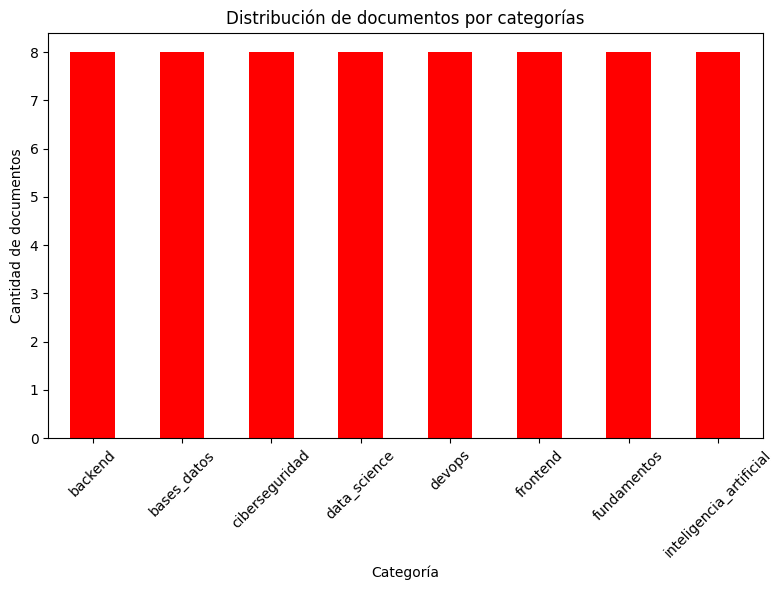

In [5]:
#Distribución por categorias
import matplotlib.pyplot as plt

conteo_categorias = df['categoria'].value_counts()
print(conteo_categorias)

conteo_categorias.plot(kind='bar', figsize=(8, 6), color='red')
plt.title('Distribución de documentos por categorías')
plt.xlabel('Categoría')
plt.ylabel('Cantidad de documentos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

count    64.000000
mean     39.203125
std       5.152222
min      30.000000
25%      35.000000
50%      38.000000
75%      42.250000
max      51.000000
Name: cantidad_palabras, dtype: float64


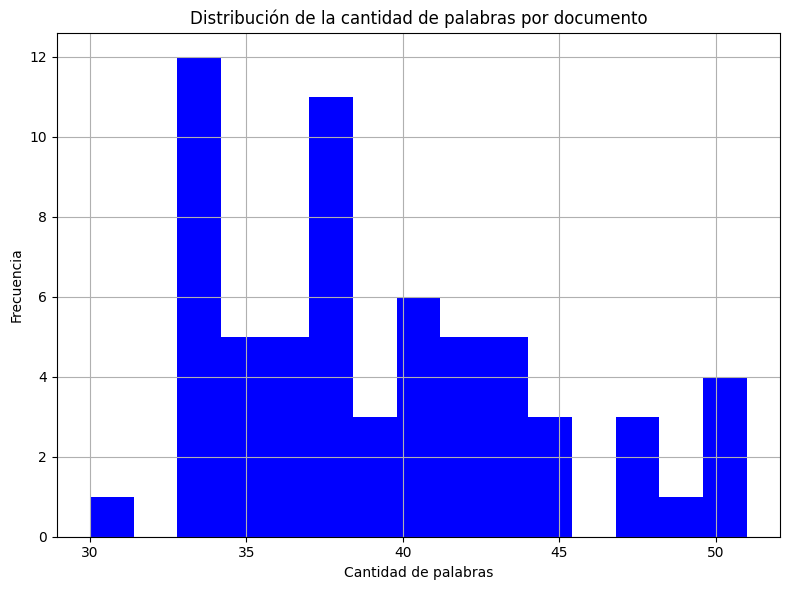

<Axes: xlabel='categoria'>

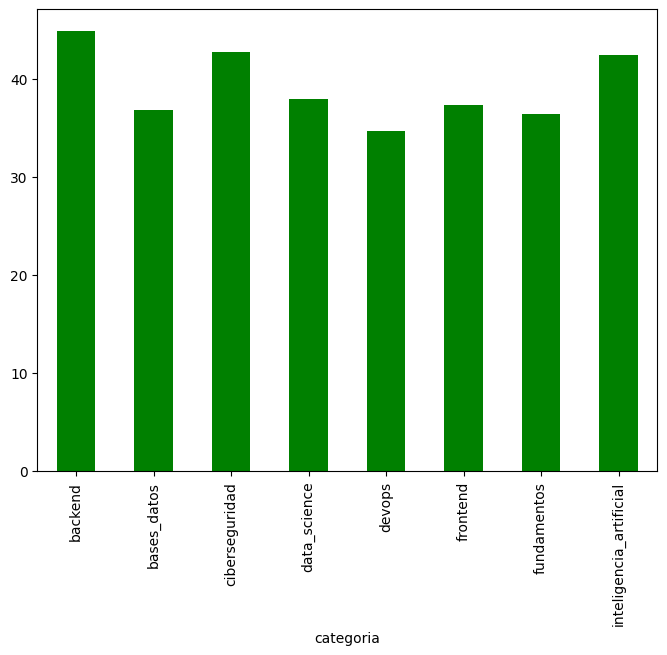

In [7]:
# Longitud de textos

df['cantidad_palabras'] = df['texto'].apply(lambda x: len(str(x).split()))
print(df['cantidad_palabras'].describe())

df['cantidad_palabras'].hist(bins=15, figsize=(8, 6), color='blue')
plt.title('Distribución de la cantidad de palabras por documento')
plt.xlabel('Cantidad de palabras')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

# Longitud pormedio por categoria
df.groupby('categoria')['cantidad_palabras'].mean().plot(kind='bar', figsize=(8, 6), color='green')

In [8]:
# Palabras mas frecuentes

from collections import Counter

todas_las_palabras = ' '.join(df['texto'].str.lower()).split()
frecuencia = Counter(todas_las_palabras)

print('Top 20 palabras mas frecuenetes en el dataset:')
for palabra, cantidad in frecuencia.most_common(20):
    print(f'{palabra}: {cantidad}')


Top 20 palabras mas frecuenetes en el dataset:
de: 181
la: 66
que: 65
un: 63
el: 61
y: 59
una: 58
en: 52
es: 37
como: 34
para: 33
a: 30
datos: 25
las: 24
o: 23
los: 22
se: 21
permite: 18
con: 17
del: 15


In [ ]:
# Detectar duplicados
duplicados = df.[df.duplicated]